In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
from time import time
from matplotlib import pyplot as plt

from DynamicTimeAllocationModel import HouseholdModelClass
from figure_manager import FigureManager

path = 'output/'

# c++ settings
do_compile = False
threads = 40

# from EconModel import cpptools
# cpptools.setup_nlopt(folder='cppfuncs/', do_print=True)

# Solve and simulate model

In [2]:
filename = 'calibrated_par'
with open(f"par_files/{filename}.pkl", "rb") as f:
    settings = pickle.load(f)

In [3]:
# setup model
model = HouseholdModelClass(par=settings)
model.link_to_cpp(force_compile=do_compile)

# solve and simulate baseline model
model.solve()
model.simulate()

In [4]:
# setup model_full
model_full = HouseholdModelClass(par={**settings, 'bargaining': 'full'})
model_full.link_to_cpp(force_compile=do_compile)

# solve and simulate baseline model_full
model_full.solve()
model_full.simulate()

In [5]:
model_shock = model.copy()
model_full_shock = model_full.copy()

In [6]:
models = {
    'baseline': model,
    'shock': model_shock,
    'baseline_full': model_full,
    'shock_full': model_full_shock
}

## Visualize precomputed consumption

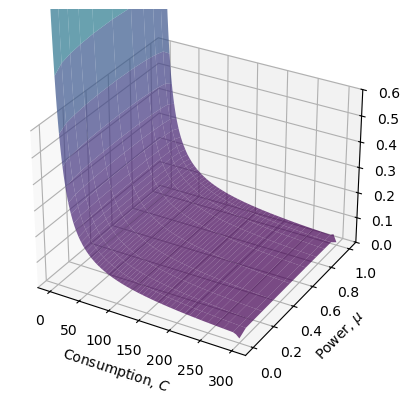

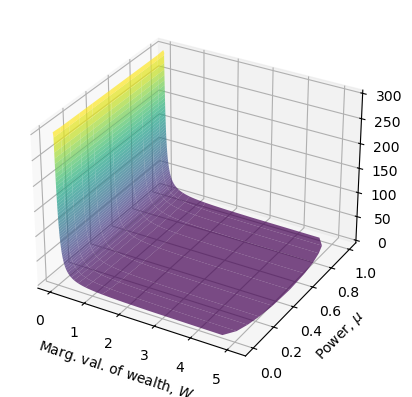

In [7]:
grid_C = model.par.grid_C_for_marg_u
grid_power = model.par.grid_power

X, Y = np.meshgrid(grid_C, grid_power)

min_C_idx = 1
ilw = -1
ilm = -1
grid_marg_u = model.sol.grid_marg_u_couple[ilw,ilm]


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X[:,min_C_idx:], Y[:,min_C_idx:], grid_marg_u[:,min_C_idx:],alpha=0.7, cmap='viridis')
ax.set(xlabel=r'Consumption, $C$', ylabel=r'Power, $\mu$', zlim=(0.0, 0.6));
fig.savefig('output/application_iEGM_interp_W.pdf', bbox_inches='tight')


fig = plt.figure()
ax = fig.add_subplot(projection='3d')  
ax.plot_surface(grid_marg_u[:,min_C_idx:], Y[:,min_C_idx:], X[:,min_C_idx:],alpha=0.7, cmap='viridis')
ax.set(xlabel=r'Marg. val. of wealth, $W$', ylabel=r'Power, $\mu$');
fig.savefig('output/application_iEGM_interp_C.pdf', bbox_inches='tight')

## Love shocks
Introduce a large shock in a specific period

In [8]:
age_min = 25
age_shock = 35
size_shock = 0.75
t_shock = age_shock-age_min

for name, mdl in models.items():
    mdl.draw_shocks()
    if 'shock' in name:
        mdl.sim.draw_love[:,t_shock] = -5.0
        mdl.sim.draw_repartner_love[:,t_shock] = -5.0
    mdl.simulate()
    

In [9]:
# # for var in ('draw_shock_Kw','draw_love','love','Kw','Km','Cw_priv','Cm_priv','C_tot','Qw','hw','hm','lw','lm','couple','power','wage_w','wage_m'):
# for var in ('draw_love','love','couple','power',):
#     fig,ax = plt.subplots()
#     for name, mdl in models.items():
#         series = np.nanmean(getattr(mdl.sim,var),axis=0)
#         age = 25+np.arange(series.size)
#         ax.plot(age,series,label=name)
#     ax.set(title=var,xlabel='age',ylabel='level')
#     ax.axvline(age_shock,color='gray',linestyle='--')
#     if var == 'C_ineq_90_10':
#         colors = ['blue', 'orange', 'green', 'red']
#         i = 0
#         for name, mdl in models.items():
#             moms = mdl.calc_moments()
#             ax.axhline(moms['consumption_90_10_ratio'],color=colors[i], linestyle='--',label=f'{name} data')
#             i += 1
#     ax.legend()

## Productivity (human capital) shocks

In [10]:
def impulse_response(ax, var, models, type='low', title=None, ylim=None):
        
    ax.axhline(0,color='black',linestyle=':', alpha=0.5, linewidth=1)
    ax.axvline(age_shock,color='grey',linestyle='--', linewidth=1)
    ax.set(title=title or var,xlabel='Age',ylabel='% dev. from baseline')
        
    # replace X in var with w
    var_w = var.replace('X','w')
    var_m = var.replace('X','m')
    
    if type == 'low':
        mask_type_w = ((models['shock'].sim.init_type_w == 0) | (models['shock'].sim.init_type_w == 1))
        mask_type_m = ((models['shock'].sim.init_type_m == 0) | (models['shock'].sim.init_type_m == 1))
       
    if type == 'high':
        mask_type_w = ((models['shock'].sim.init_type_w == 2) | (models['shock'].sim.init_type_w == 3))
        mask_type_m = ((models['shock'].sim.init_type_m == 2) | (models['shock'].sim.init_type_m == 3))
        
    # limited
    shock_w = getattr(models['shock'].sim,var_w)[mask_type_w,:]
    shock_m = getattr(models['shock'].sim,var_m)[mask_type_m,:]
    shock = np.concatenate([shock_w, shock_m], axis=0)
    
    base_w = getattr(models['baseline'].sim,var_w)[mask_type_w,:]
    base_m = getattr(models['baseline'].sim,var_m)[mask_type_m,:]
    base = np.concatenate([base_w, base_m], axis=0)
    
    limited = np.nanmean(shock,axis=0) / np.nanmean(base,axis=0) - 1.0
    age = 25+np.arange(limited.size)
    ax.plot(age,limited,label='Limited commitment', alpha=1.0)
    
    
    # full
    shock_w = getattr(models['shock_full'].sim,var_w)[mask_type_w,:]
    shock_m = getattr(models['shock_full'].sim,var_m)[mask_type_m,:]
    shock = np.concatenate([shock_w, shock_m], axis=0)
    
    base_w = getattr(models['baseline_full'].sim,var_w)[mask_type_w,:]
    base_m = getattr(models['baseline_full'].sim,var_m)[mask_type_m,:]
    base = np.concatenate([base_w, base_m], axis=0)
    
    full = np.nanmean(shock,axis=0) / np.nanmean(base,axis=0) - 1.0
    age = 25+np.arange(full.size)
    ax.plot(age,full,label='Full commitment', alpha=1.0)
    
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # make y axis percent
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.1f}%'))
    ax.legend()

In [1]:
age_min = 25
age_shock = 30
size_shock = - 0.75
t_shock = age_shock-age_min

### Shock to low types human capital

In [2]:
for name, mdl in models.items():
    mdl.draw_shocks()
    if 'shock' in name:
        low_type_w = ((mdl.sim.init_type_w == 0) | (mdl.sim.init_type_w == 1))
        low_type_m = ((mdl.sim.init_type_m == 0) | (mdl.sim.init_type_m == 1))
        mdl.sim.draw_shock_Kw[low_type_w,t_shock] = 1 + size_shock
        mdl.sim.draw_shock_Km[low_type_m,t_shock] = 1 + size_shock
    mdl.simulate()
    

NameError: name 'models' is not defined

Impulse responses

Saved full figure to output\shock_Klow.pdf
Saved subplot to output\shock_Klow_subplot_1.pdf
Saved subplot to output\shock_Klow_subplot_2.pdf
Saved subplot to output\shock_Klow_subplot_3.pdf
Saved subplot to output\shock_Klow_subplot_4.pdf
Saved subplot to output\shock_Klow_subplot_5.pdf
Saved subplot to output\shock_Klow_subplot_6.pdf
Saved subplot to output\shock_Klow_subplot_7.pdf
Saved subplot to output\shock_Klow_subplot_8.pdf
Saved subplot to output\shock_Klow_subplot_9.pdf


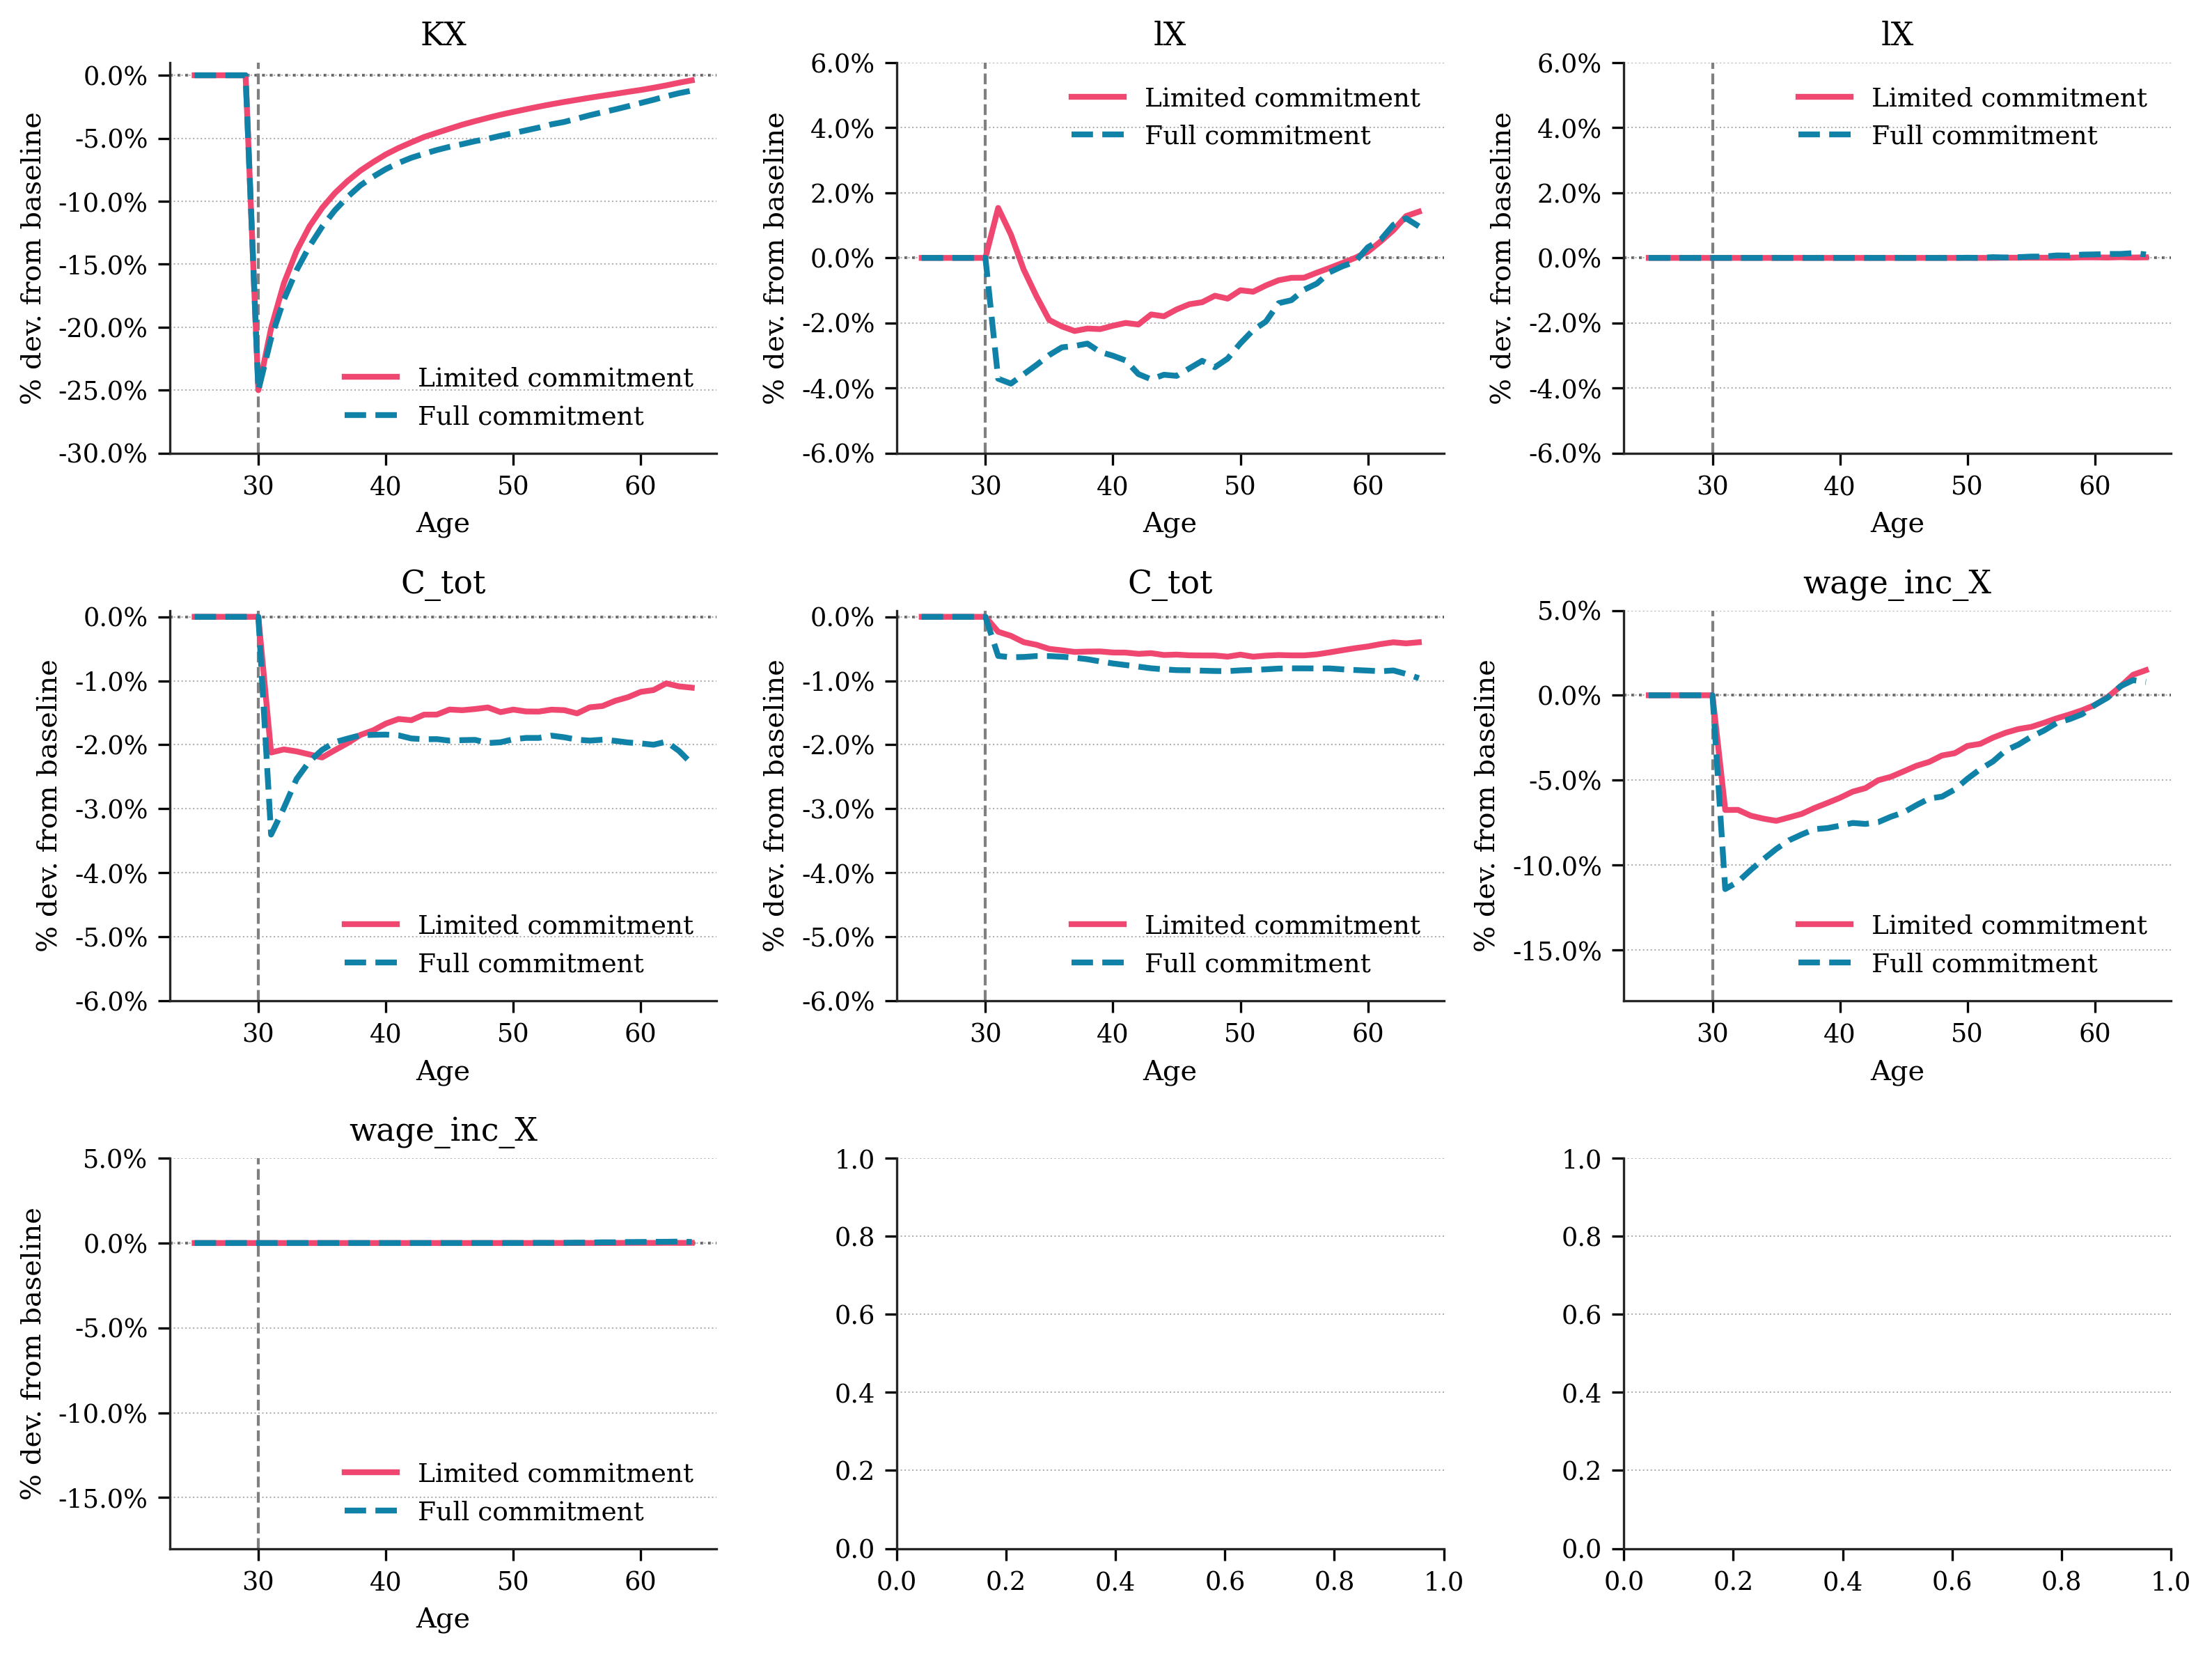

In [ ]:
fm = FigureManager(path, use_latex=False, cycle_linestyles=True)
fig, axes = fm.create_figure(3,3,9, horizontal=True)
impulse_response(axes[0], 'KX', models, type='low', ylim=(-0.30,0.01))
impulse_response(axes[1], 'lX', models, type='low', ylim=(-0.06,0.06))
impulse_response(axes[2], 'lX', models, type='high', ylim=(-0.06,0.06))
impulse_response(axes[3], 'C_tot', models, type='low', ylim=(-0.06,0.001))
impulse_response(axes[4], 'C_tot', models, type='high', ylim=(-0.06,0.001))
impulse_response(axes[5], 'wage_inc_X', models, type='low', ylim=(-0.18,0.05))
impulse_response(axes[6], 'wage_inc_X', models, type='high', ylim=(-0.18,0.05))

fig.tight_layout()
fm.save_figure(filename="shock_Klow", include_title=True)

Saved full figure to output\shock_Klow_couple.pdf
Saved subplot to output\shock_Klow_couple_subplot_1.pdf
Saved subplot to output\shock_Klow_couple_subplot_2.pdf


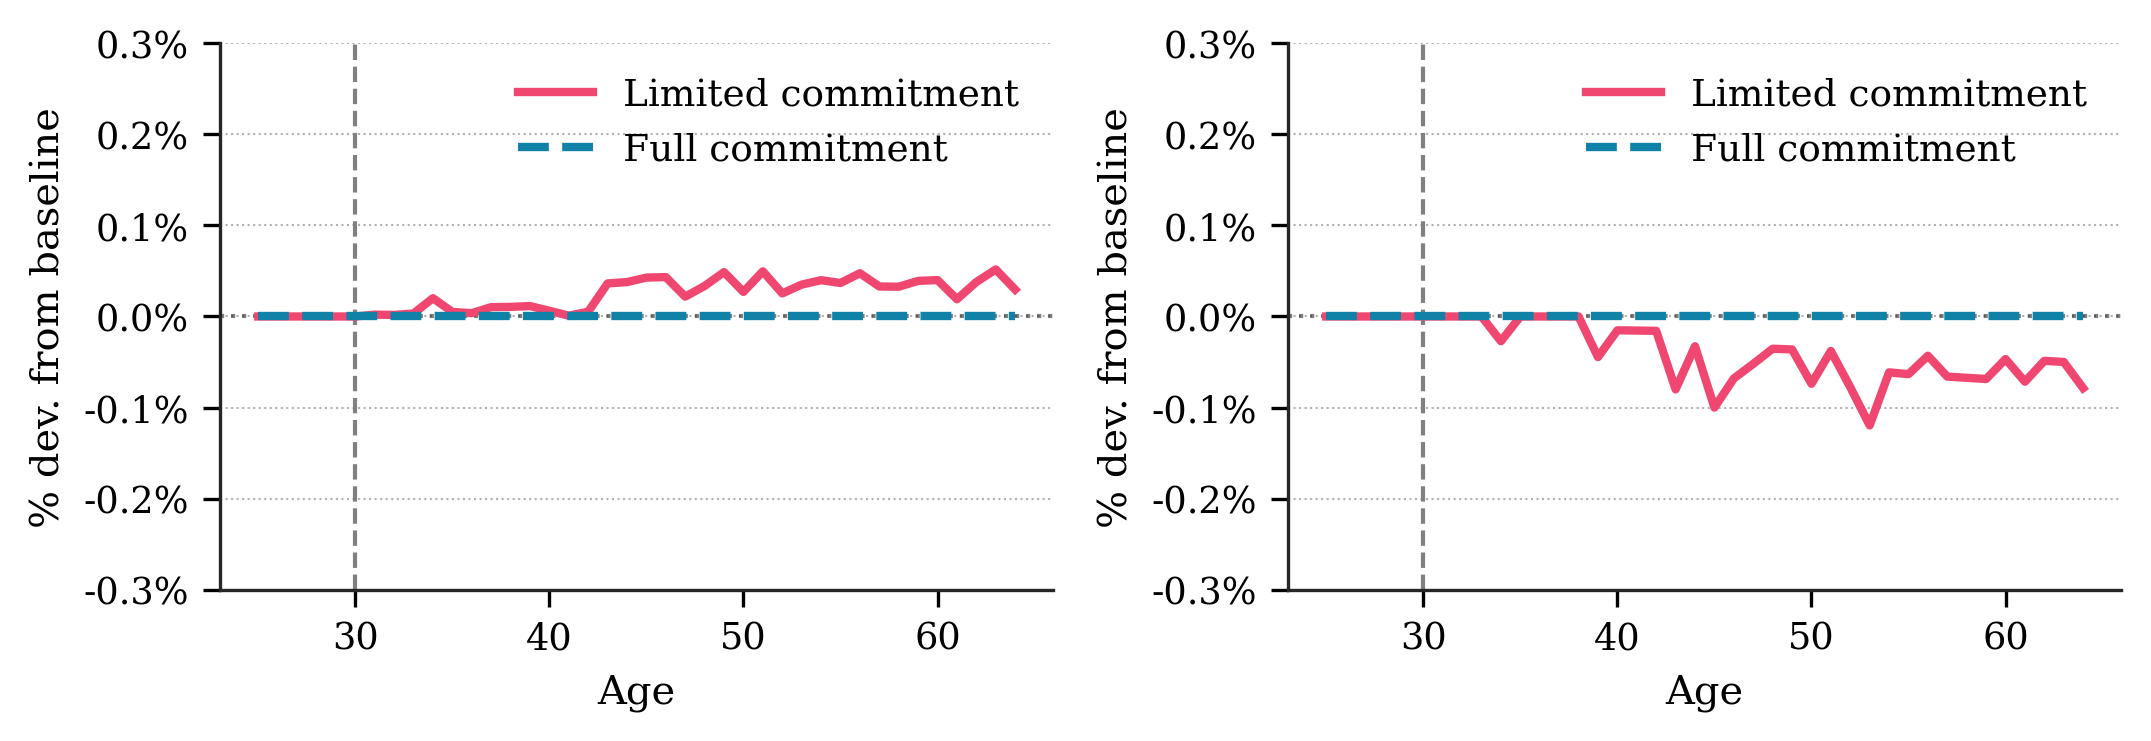

In [ ]:
fm = FigureManager(path, use_latex=False, cycle_linestyles=True)
fig, axes = fm.create_figure(1,2,2, horizontal=False)
impulse_response(axes[0], 'power', models, ylim=(-0.003,0.003))
impulse_response(axes[1], 'couple', models, ylim=(-0.003,0.003))

fig.tight_layout()
fm.save_figure(filename="shock_Klow_couple", include_title=False)

Table

In [ ]:
results = {}
for name, mdl in models.items():
    moms = mdl.calc_moments()
    if name not in results:
            results[name] = {}
    results[name]['C_ineq'] = moms['consumption_90_10_ratio']
    results[name]['wage_ineq'] = moms['wage_90_10_ratio']
    results[name]['female_consumption_share'] = moms['female_consumption_share']

In [ ]:
# Build LaTeX table from `results` with outer category = limited/full
metrics = ["C_ineq", "wage_ineq", 'female_consumption_share']

def fmt(x):
    return f"{x:.3f}"

def fmt_diff(x):
    return f"{x:+.3f}"  # shock - baseline

lines = []
lines.append(r"\begin{tabular}{lcccccc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{3}{c}{Limited Commitment} & \multicolumn{3}{c}{Full Commitment} \\")
lines.append(r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}")
lines.append(r"Moment & Baseline & Shock & Diff & Baseline & Shock & Diff \\")
lines.append(r"\midrule")

for m in metrics:
    b_lim = results["baseline"][m]
    s_lim = results["shock"][m]
    d_lim = s_lim - b_lim

    b_full = results["baseline_full"][m]
    s_full = results["shock_full"][m]
    d_full = s_full - b_full

    row_name = m.replace("_", r"\_")
    lines.append(
        f"{row_name} & "
        f"{fmt(b_lim)} & {fmt(s_lim)} & {fmt_diff(d_lim)} & "
        f"{fmt(b_full)} & {fmt(s_full)} & {fmt_diff(d_full)} \\\\"
    )

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")

latex_table = "\n".join(lines)
print(latex_table)

# Optional: save table
with open(f"{path}shock_table_Klow.tex", "w") as f:
    f.write(latex_table)

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{Limited Commitment} & \multicolumn{3}{c}{Full Commitment} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
Moment & Baseline & Shock & Diff & Baseline & Shock & Diff \\
\midrule
C\_ineq & 3.759 & 3.793 & +0.035 & 3.508 & 3.579 & +0.071 \\
wage\_ineq & 3.850 & 3.899 & +0.049 & 3.581 & 3.652 & +0.071 \\
female\_consumption\_share & 0.498 & 0.498 & +0.000 & 0.486 & 0.486 & -0.000 \\
\bottomrule
\end{tabular}


### Shock to high types human capital

In [ ]:
for name, mdl in models.items():
    mdl.draw_shocks()
    if 'shock' in name:
        high_type_w = ((mdl.sim.init_type_w == 2) | (mdl.sim.init_type_w == 3))
        high_type_m = ((mdl.sim.init_type_m == 2) | (mdl.sim.init_type_m == 3))
        mdl.sim.draw_shock_Kw[high_type_w,t_shock] = 1 + size_shock
        mdl.sim.draw_shock_Km[high_type_m,t_shock] = 1 + size_shock
    mdl.simulate()
    

Impulse responses

Saved full figure to output\shock_Khigh.pdf
Saved subplot to output\shock_Khigh_subplot_1.pdf
Saved subplot to output\shock_Khigh_subplot_2.pdf
Saved subplot to output\shock_Khigh_subplot_3.pdf
Saved subplot to output\shock_Khigh_subplot_4.pdf
Saved subplot to output\shock_Khigh_subplot_5.pdf
Saved subplot to output\shock_Khigh_subplot_6.pdf
Saved subplot to output\shock_Khigh_subplot_7.pdf
Saved subplot to output\shock_Khigh_subplot_8.pdf
Saved subplot to output\shock_Khigh_subplot_9.pdf


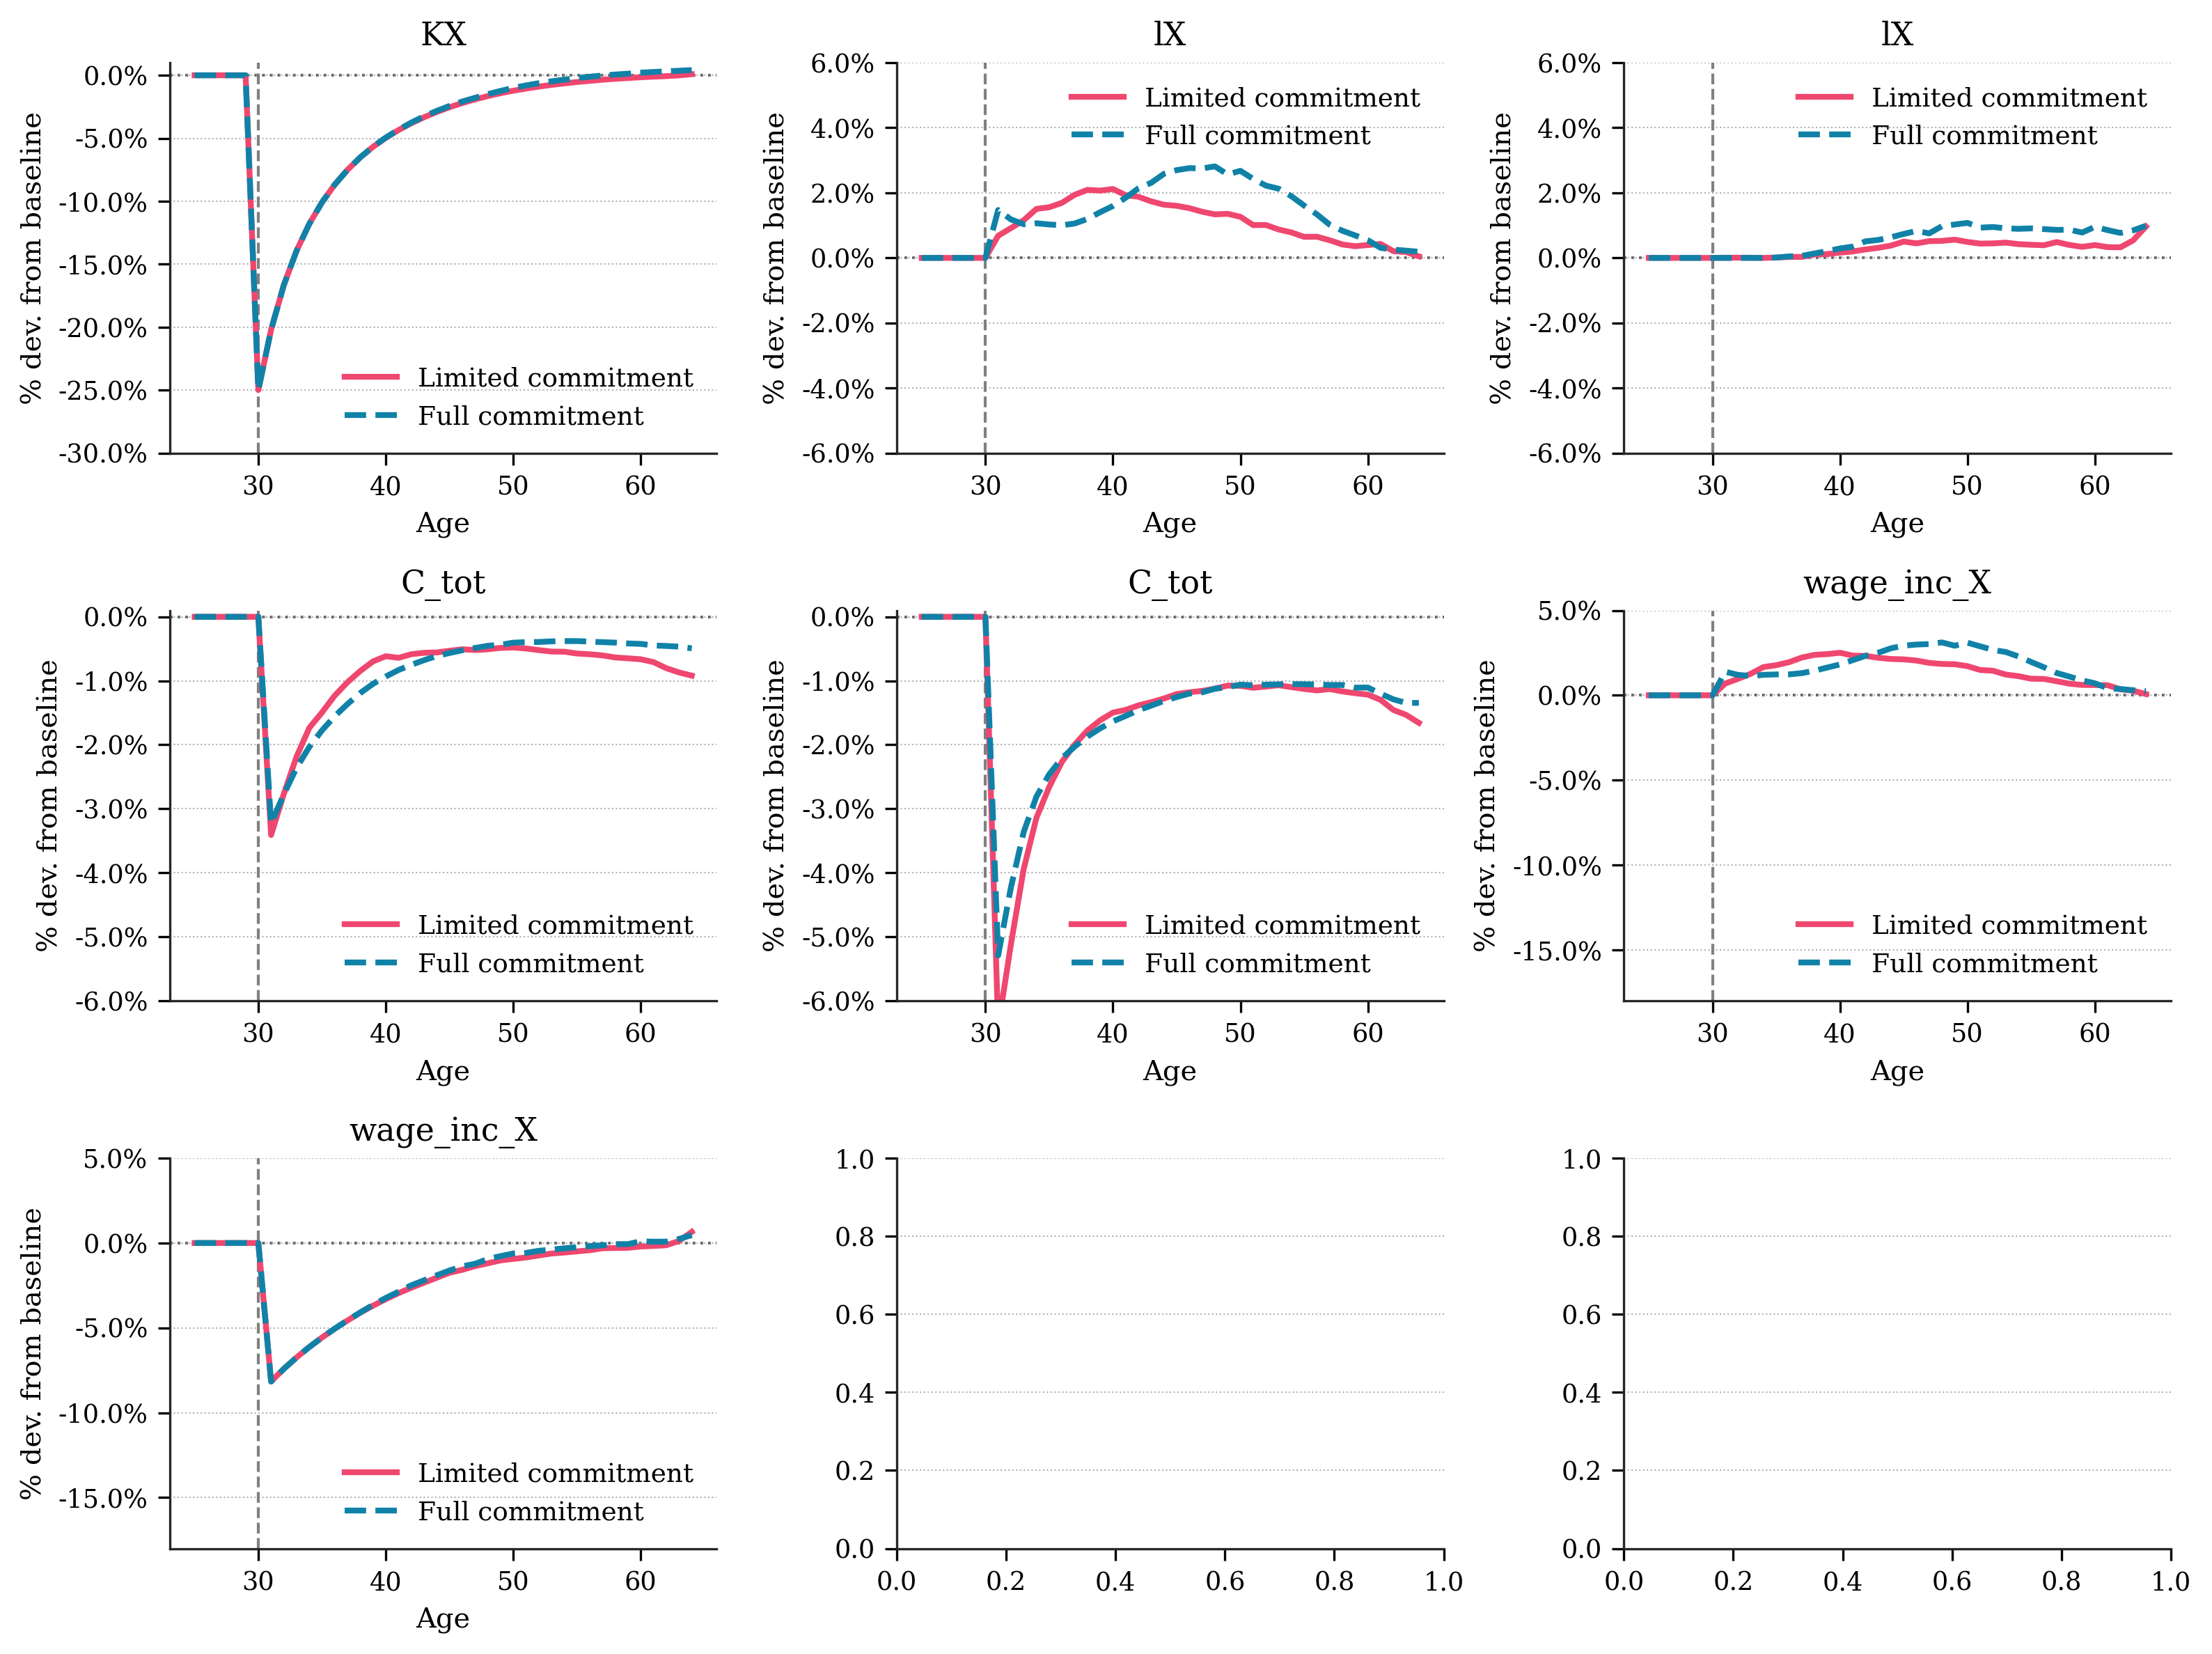

In [ ]:
fm = FigureManager(path, use_latex=False, cycle_linestyles=True)
fig, axes = fm.create_figure(3,3,9, horizontal=True)
impulse_response(axes[0], 'KX', models, type='high', ylim=(-0.30,0.01))
impulse_response(axes[1], 'lX', models, type='low', ylim=(-0.06,0.06))
impulse_response(axes[2], 'lX', models, type='high', ylim=(-0.06,0.06))
impulse_response(axes[3], 'C_tot', models, type='low', ylim=(-0.06,0.001))
impulse_response(axes[4], 'C_tot', models, type='high', ylim=(-0.06,0.001))
impulse_response(axes[5], 'wage_inc_X', models, type='low', ylim=(-0.18,0.05))
impulse_response(axes[6], 'wage_inc_X', models, type='high', ylim=(-0.18,0.05))

fig.tight_layout()
fm.save_figure(filename="shock_Khigh", include_title=True)

Saved full figure to output\shock_Khigh_couple.pdf
Saved subplot to output\shock_Khigh_couple_subplot_1.pdf
Saved subplot to output\shock_Khigh_couple_subplot_2.pdf


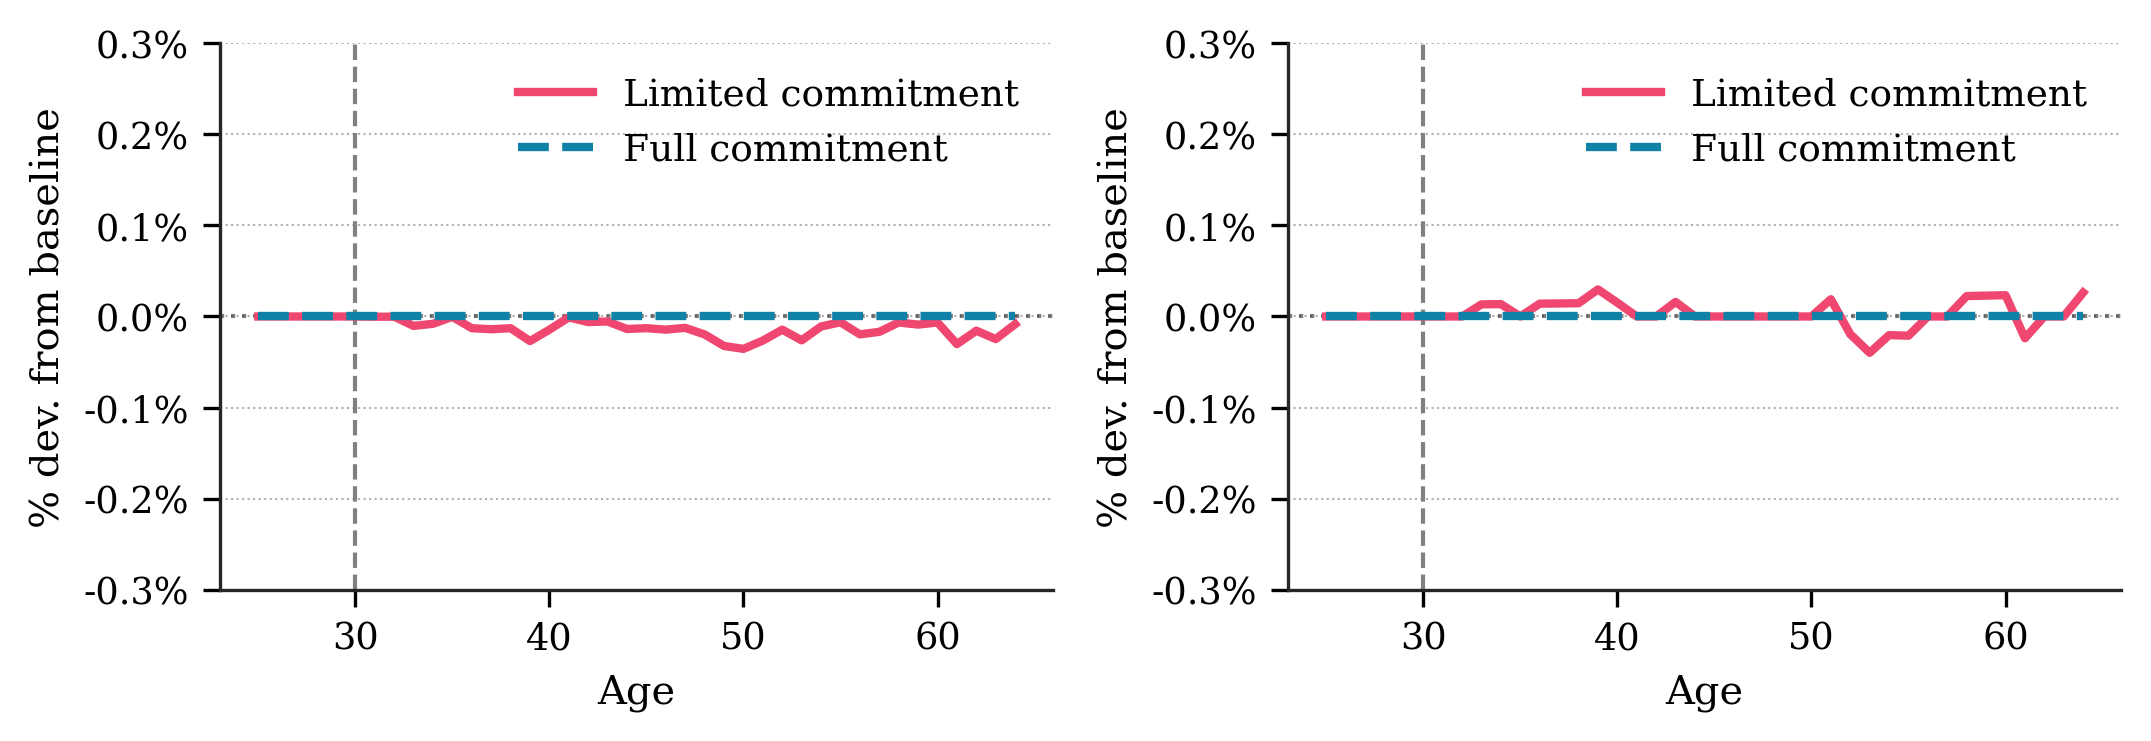

In [ ]:
fm = FigureManager(path, use_latex=False, cycle_linestyles=True)
fig, axes = fm.create_figure(1,2,2, horizontal=False)
impulse_response(axes[0], 'power', models, ylim=(-0.003,0.003))
impulse_response(axes[1], 'couple', models, ylim=(-0.003,0.003))

fig.tight_layout()
fm.save_figure(filename="shock_Khigh_couple", include_title=False)

Table

In [ ]:
results = {}
for name, mdl in models.items():
    moms = mdl.calc_moments()
    if name not in results:
            results[name] = {}
    results[name]['C_ineq'] = moms['consumption_90_10_ratio']
    results[name]['wage_ineq'] = moms['wage_90_10_ratio']
    results[name]['female_consumption_share'] = moms['female_consumption_share']

In [ ]:
# Build LaTeX table from `results` with outer category = limited/full
metrics = ["C_ineq", "wage_ineq", 'female_consumption_share']

def fmt(x):
    return f"{x:.3f}"

def fmt_diff(x):
    return f"{x:+.3f}"  # shock - baseline

lines = []
lines.append(r"\begin{tabular}{lcccccc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{3}{c}{Limited Commitment} & \multicolumn{3}{c}{Full Commitment} \\")
lines.append(r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}")
lines.append(r"Moment & Baseline & Shock & Diff & Baseline & Shock & Diff \\")
lines.append(r"\midrule")

for m in metrics:
    b_lim = results["baseline"][m]
    s_lim = results["shock"][m]
    d_lim = s_lim - b_lim

    b_full = results["baseline_full"][m]
    s_full = results["shock_full"][m]
    d_full = s_full - b_full

    row_name = m.replace("_", r"\_")
    lines.append(
        f"{row_name} & "
        f"{fmt(b_lim)} & {fmt(s_lim)} & {fmt_diff(d_lim)} & "
        f"{fmt(b_full)} & {fmt(s_full)} & {fmt_diff(d_full)} \\\\"
    )

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")

latex_table = "\n".join(lines)
print(latex_table)

# Optional: save table
with open(f"{path}shock_table_Khigh.tex", "w") as f:
    f.write(latex_table)

\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{Limited Commitment} & \multicolumn{3}{c}{Full Commitment} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
Moment & Baseline & Shock & Diff & Baseline & Shock & Diff \\
\midrule
C\_ineq & 3.759 & 3.689 & -0.070 & 3.508 & 3.439 & -0.069 \\
wage\_ineq & 3.850 & 3.775 & -0.076 & 3.581 & 3.512 & -0.069 \\
female\_consumption\_share & 0.498 & 0.498 & -0.000 & 0.486 & 0.486 & +0.000 \\
\bottomrule
\end{tabular}
